In [1]:
import os
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

processed_path = "../data/processed/"
os.makedirs(processed_path, exist_ok=True)

OUTPUT_PATH = "model_assets/model_3/"
os.makedirs(OUTPUT_PATH, exist_ok=True)

RANDOM_SEED = 42
SAMPLE_SEED = 6420

np.random.seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

PROCESSED = pathlib.Path("../data/processed/modeling_df.parquet")
REFERENCE = pathlib.Path("../data/reference/modeling_df.parquet")

if PROCESSED.exists():
    modeling_parquet = PROCESSED
else:
    print(
        "[warning] data/processed/modeling_df.parquet not found — "
        "falling back to committed frozen reference at data/reference/. "
        "Run bin/build.sh for the fresh pipeline output."
    )
    modeling_parquet = REFERENCE

[warning] data/processed/modeling_df.parquet not found — falling back to committed frozen reference at data/reference/. Run bin/build.sh for the fresh pipeline output.


# Model 3 - Sex as group-level predictor

- Builds on Model 2b winner: Student-t + per-subject sigma + subject intercepts
- Subject intercepts now partially pool toward sex-specific means
- Sex means themselves partially pool toward a grand mean (weak pooling with only 2 groups)
- First demographic predictor in the audit chain

### Outcome
- cadence_error per trial (spm, continuous, two-sided)
- Pelvis IMU minus force-plate cadence

### Key question
Does sex explain any of the left-shoulder asymmetry that Model 2b couldn't absorb?
- If F and M pool toward similar means and the PPC doesn't improve, sex is not the story.
- If F and M have detectably different means, that's an audit finding: the algorithm is biased differently for women than men on average.
- Either answer is publishable given the audit framing.

## Load data, build modeling frame
- Load modeling_df.parquet
- Filter to modeling_include==True

In [2]:
df_all = pd.read_parquet(modeling_parquet)
df = df_all[df_all["modeling_include"]].copy()

print('Cadence Error Summary')
print(df["cadence_error"].describe().round(2))

assert len(df) == 2781, f"Expected 2781 trials, got {len(df)}"
assert df["subject_id"].nunique() == 47, f"Expected 47 subjects, got {df['subject_id'].nunique()}"
assert df["cadence_error"].isnull().sum() == 0, "cadence_error contains null values"

Cadence Error Summary
count    2781.00
mean       -5.52
std        11.22
min       -74.28
25%        -7.09
50%        -2.96
75%        -0.40
max        33.57
Name: cadence_error, dtype: float64


## Build coordinates, indices, and speed dummies
- Same structure as Models 1 and 2
- `sex_of_subject_idx` is now load-bearing (Model 3 is the first to use it)
- Sex is a subject-level variable, not trial-level: each subject has one sex that applies to all their trials

In [3]:
subject_ids = sorted(df['subject_id'].unique())
coords = {
    'subject': subject_ids,
    'sex': ['F', 'M'],
    'speed_nonref': ['slow','fast'],
    'obs': np.arange(len(df))
}

subject_idx = pd.Categorical(df['subject_id'], categories=coords['subject']).codes

subjects_df = (
    df[['subject_id', 'sex']]
    .drop_duplicates()
    .set_index('subject_id')
    .loc[coords['subject']]
    .reset_index()
)
sex_of_subject_idx = pd.Categorical(subjects_df['sex'], categories=coords['sex']).codes

speed_dummies = pd.get_dummies(df['speed'])
slow_dummy = speed_dummies['slow'].to_numpy().astype(float)
fast_dummy = speed_dummies['fast'].to_numpy().astype(float)

cadence_error = df['cadence_error'].to_numpy()

assert len(subject_idx) == len(df)
assert subject_idx.min() == 0 and subject_idx.max() == 46
assert len(sex_of_subject_idx) == 47
assert sex_of_subject_idx.sum() == 30
assert slow_dummy.sum() + fast_dummy.sum() + (df["speed"] == "comf").sum() == len(df)

print(f"subjects: {len(coords['subject'])}")
print(f"subject_idx range: [{subject_idx.min()}, {subject_idx.max()}]")
print(f"F/M: {(sex_of_subject_idx == 0).sum()}/{(sex_of_subject_idx == 1).sum()}")
print(f"speed: comf={(df['speed']=='comf').sum()}, slow={int(slow_dummy.sum())}, fast={int(fast_dummy.sum())}")

subjects: 47
subject_idx range: [0, 46]
F/M: 17/30
speed: comf=933, slow=928, fast=920


## Model 3: Sex as group-level predictor

Builds on Model 2b. Keeps Student-t likelihood and per-subject sigma_obs. Changes: subject intercepts now partially pool toward sex-specific means instead of a global mu_pop.

### Structure
- 2 sex means `alpha_sex[F, M]`, partially pooled toward grand mean `mu_pop`
- 47 subject intercepts `alpha_subject[s]`, partially pooled toward the sex mean of that subject's sex
- Two-level hierarchy: subject within sex within population

### Priors
- `mu_pop ~ Normal(0, 10)`: grand mean
- `sigma_sex ~ HalfNormal(5)`: how much F and M means differ. Weak with only 2 groups.
- `alpha_sex ~ Normal(mu_pop, sigma_sex)` dims=sex: per-sex intercept
- `sigma_subject ~ HalfNormal(5)`: how subjects vary within their sex
- `alpha_subject ~ Normal(alpha_sex[sex_of_subject], sigma_subject)` dims=subject
- `nu ~ Gamma(2, 0.1)`: Student-t df
- `beta_slow ~ Normal(0, 5)`, `beta_fast ~ Normal(0, 5)`: speed effects
- `sigma_obs_scale ~ HalfNormal(10)`: hyperprior on per-subject noise
- `sigma_obs ~ HalfNormal(sigma_obs_scale)` dims=subject: per-subject noise

### Note on 2-group partial pooling
With 2 sex groups, `sigma_sex` has almost no data to estimate itself. The hyperprior on sigma_sex will dominate. That's expected and documented, not a bug.

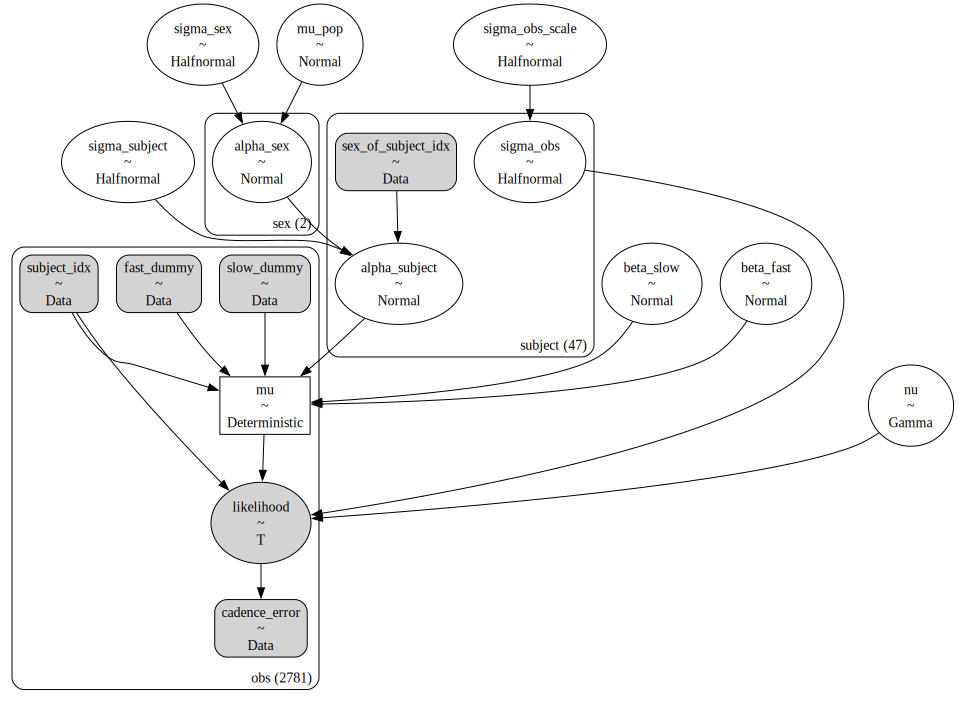

In [4]:
with pm.Model(coords=coords) as model_3:

    slow = pm.Data('slow_dummy', slow_dummy, dims='obs')
    fast = pm.Data('fast_dummy', fast_dummy, dims='obs')
    sidx = pm.Data('subject_idx', subject_idx, dims='obs')
    ssex = pm.Data('sex_of_subject_idx', sex_of_subject_idx, dims='subject')
    y = pm.Data('cadence_error', cadence_error, dims='obs')

    mu_pop = pm.Normal('mu_pop', mu=0, sigma=10)
    sigma_sex = pm.HalfNormal('sigma_sex', sigma=5)
    alpha_sex = pm.Normal('alpha_sex', mu=mu_pop, sigma=sigma_sex, dims='sex')

    sigma_subject = pm.HalfNormal('sigma_subject', sigma=5)
    alpha_subject = pm.Normal(
        'alpha_subject',
        mu=alpha_sex[ssex],
        sigma=sigma_subject,
        dims='subject'
    )

    sigma_obs_scale = pm.HalfNormal('sigma_obs_scale', sigma=10)
    sigma_obs = pm.HalfNormal('sigma_obs', sigma=sigma_obs_scale, dims='subject')

    nu = pm.Gamma('nu', alpha=2, beta=0.1)
    beta_slow = pm.Normal('beta_slow', mu=0, sigma=5)
    beta_fast = pm.Normal('beta_fast', mu=0, sigma=5)

    mu = pm.Deterministic(
        'mu',
        alpha_subject[sidx] + beta_slow * slow + beta_fast * fast,
        dims='obs'
    )

    pm.StudentT('likelihood', nu=nu, mu=mu, sigma=sigma_obs[sidx], observed=y, dims='obs')

_dag = pm.model_to_graphviz(model_3)
_dag.render(f"{OUTPUT_PATH}model_3_dag", format="png", cleanup=True)
_dag

In [5]:
with model_3:
    idata_model_3 = pm.sample(
        draws=2000, tune=2000, chains=4,
        target_accept=0.95, random_seed=SAMPLE_SEED,
        idata_kwargs={"log_likelihood": True}
    )
    pm.sample_posterior_predictive(
        idata_model_3, extend_inferencedata=True, random_seed=SAMPLE_SEED
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_pop, sigma_sex, alpha_sex, sigma_subject, alpha_subject, sigma_obs_scale, sigma_obs, nu, beta_slow, beta_fast]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 28 seconds.
There were 422 divergences after tuning. Increase `target_accept` or reparameterize.
Sampling: [likelihood]


Output()

## 422 divergences. Non-centering the sex level.

Funnel geometry on `sigma_sex` with only 2 groups. Classic centered-parameterization failure. Rewriting as:
alpha_sex_offset ~ Normal(0, 1) dims=sex
alpha_sex = mu_pop + sigma_sex * alpha_sex_offset

Same prior on `alpha_sex` implicitly, different geometry for the sampler. If divergences persist, will non-center `alpha_subject` too.

In [6]:
with pm.Model(coords=coords) as model_3:

    slow = pm.Data('slow_dummy', slow_dummy, dims='obs')
    fast = pm.Data('fast_dummy', fast_dummy, dims='obs')
    sidx = pm.Data('subject_idx', subject_idx, dims='obs')
    ssex = pm.Data('sex_of_subject_idx', sex_of_subject_idx, dims='subject')
    y = pm.Data('cadence_error', cadence_error, dims='obs')

    mu_pop = pm.Normal('mu_pop', mu=0, sigma=10)
    sigma_sex = pm.HalfNormal('sigma_sex', sigma=5)

    # non-centered alpha_sex
    alpha_sex_offset = pm.Normal('alpha_sex_offset', mu=0, sigma=1, dims='sex')
    alpha_sex = pm.Deterministic('alpha_sex', mu_pop + sigma_sex * alpha_sex_offset, dims='sex')

    sigma_subject = pm.HalfNormal('sigma_subject', sigma=5)
    alpha_subject = pm.Normal(
        'alpha_subject',
        mu=alpha_sex[ssex],
        sigma=sigma_subject,
        dims='subject'
    )

    sigma_obs_scale = pm.HalfNormal('sigma_obs_scale', sigma=10)
    sigma_obs = pm.HalfNormal('sigma_obs', sigma=sigma_obs_scale, dims='subject')

    nu = pm.Gamma('nu', alpha=2, beta=0.1)
    beta_slow = pm.Normal('beta_slow', mu=0, sigma=5)
    beta_fast = pm.Normal('beta_fast', mu=0, sigma=5)

    mu = pm.Deterministic(
        'mu',
        alpha_subject[sidx] + beta_slow * slow + beta_fast * fast,
        dims='obs'
    )

    pm.StudentT('likelihood', nu=nu, mu=mu, sigma=sigma_obs[sidx], observed=y, dims='obs')

with model_3:
    idata_model_3 = pm.sample(
        draws=2000, tune=2000, chains=4,
        target_accept=0.95, random_seed=SAMPLE_SEED,
        idata_kwargs={"log_likelihood": True}
    )
    pm.sample_posterior_predictive(
        idata_model_3, extend_inferencedata=True, random_seed=SAMPLE_SEED
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_pop, sigma_sex, alpha_sex_offset, sigma_subject, alpha_subject, sigma_obs_scale, sigma_obs, nu, beta_slow, beta_fast]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 32 seconds.
There were 110 divergences after tuning. Increase `target_accept` or reparameterize.
Sampling: [likelihood]


Output()

## Still 110 divergences. Non-centering alpha_subject too.

Non-centering alpha_sex helped (422 -> 110) but not enough. Next layer: alpha_subject.

```
alpha_subject_offset ~ Normal(0, 1) dims=subject
alpha_subject = alpha_sex[ssex] + sigma_subject * alpha_subject_offset
```

In [7]:
with pm.Model(coords=coords) as model_3:

    slow = pm.Data('slow_dummy', slow_dummy, dims='obs')
    fast = pm.Data('fast_dummy', fast_dummy, dims='obs')
    sidx = pm.Data('subject_idx', subject_idx, dims='obs')
    ssex = pm.Data('sex_of_subject_idx', sex_of_subject_idx, dims='subject')
    y = pm.Data('cadence_error', cadence_error, dims='obs')

    mu_pop = pm.Normal('mu_pop', mu=0, sigma=10)
    sigma_sex = pm.HalfNormal('sigma_sex', sigma=5)

    alpha_sex_offset = pm.Normal('alpha_sex_offset', mu=0, sigma=1, dims='sex')
    alpha_sex = pm.Deterministic('alpha_sex', mu_pop + sigma_sex * alpha_sex_offset, dims='sex')

    sigma_subject = pm.HalfNormal('sigma_subject', sigma=5)
    alpha_subject_offset = pm.Normal('alpha_subject_offset', mu=0, sigma=1, dims='subject')
    alpha_subject = pm.Deterministic(
        'alpha_subject',
        alpha_sex[ssex] + sigma_subject * alpha_subject_offset,
        dims='subject'
    )

    sigma_obs_scale = pm.HalfNormal('sigma_obs_scale', sigma=10)
    sigma_obs = pm.HalfNormal('sigma_obs', sigma=sigma_obs_scale, dims='subject')

    nu = pm.Gamma('nu', alpha=2, beta=0.1)
    beta_slow = pm.Normal('beta_slow', mu=0, sigma=5)
    beta_fast = pm.Normal('beta_fast', mu=0, sigma=5)

    mu = pm.Deterministic(
        'mu',
        alpha_subject[sidx] + beta_slow * slow + beta_fast * fast,
        dims='obs'
    )

    pm.StudentT('likelihood', nu=nu, mu=mu, sigma=sigma_obs[sidx], observed=y, dims='obs')

with model_3:
    idata_model_3 = pm.sample(
        draws=2000, tune=2000, chains=4,
        target_accept=0.95, random_seed=SAMPLE_SEED,
        idata_kwargs={"log_likelihood": True}
    )
    pm.sample_posterior_predictive(
        idata_model_3, extend_inferencedata=True, random_seed=SAMPLE_SEED
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_pop, sigma_sex, alpha_sex_offset, sigma_subject, alpha_subject_offset, sigma_obs_scale, sigma_obs, nu, beta_slow, beta_fast]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 137 seconds.
There were 140 divergences after tuning. Increase `target_accept` or reparameterize.
Sampling: [likelihood]


Output()

In [8]:
with pm.Model(coords=coords) as model_3:

    slow = pm.Data('slow_dummy', slow_dummy, dims='obs')
    fast = pm.Data('fast_dummy', fast_dummy, dims='obs')
    sidx = pm.Data('subject_idx', subject_idx, dims='obs')
    ssex = pm.Data('sex_of_subject_idx', sex_of_subject_idx, dims='subject')
    y = pm.Data('cadence_error', cadence_error, dims='obs')

    mu_pop = pm.Normal('mu_pop', mu=0, sigma=10)
    sigma_sex = pm.HalfNormal('sigma_sex', sigma=5)

    alpha_sex_offset = pm.Normal('alpha_sex_offset', mu=0, sigma=1, dims='sex')
    alpha_sex = pm.Deterministic('alpha_sex', mu_pop + sigma_sex * alpha_sex_offset, dims='sex')

    # subjects are centered — worked fine in Model 2b with 47 subjects
    sigma_subject = pm.HalfNormal('sigma_subject', sigma=5)
    alpha_subject = pm.Normal(
        'alpha_subject',
        mu=alpha_sex[ssex],
        sigma=sigma_subject,
        dims='subject'
    )

    sigma_obs_scale = pm.HalfNormal('sigma_obs_scale', sigma=10)
    sigma_obs = pm.HalfNormal('sigma_obs', sigma=sigma_obs_scale, dims='subject')

    nu = pm.Gamma('nu', alpha=2, beta=0.1)
    beta_slow = pm.Normal('beta_slow', mu=0, sigma=5)
    beta_fast = pm.Normal('beta_fast', mu=0, sigma=5)

    mu = pm.Deterministic(
        'mu',
        alpha_subject[sidx] + beta_slow * slow + beta_fast * fast,
        dims='obs'
    )

    pm.StudentT('likelihood', nu=nu, mu=mu, sigma=sigma_obs[sidx], observed=y, dims='obs')

with model_3:
    idata_model_3 = pm.sample(
        draws=2000, tune=2000, chains=4,
        target_accept=0.99, random_seed=SAMPLE_SEED,
        idata_kwargs={"log_likelihood": True}
    )
    pm.sample_posterior_predictive(
        idata_model_3, extend_inferencedata=True, random_seed=SAMPLE_SEED
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_pop, sigma_sex, alpha_sex_offset, sigma_subject, alpha_subject, sigma_obs_scale, sigma_obs, nu, beta_slow, beta_fast]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 60 seconds.
There were 26 divergences after tuning. Increase `target_accept` or reparameterize.
Sampling: [likelihood]


Output()

Divergence journey: 422 -> 110 -> 140 -> 26.

Non-centered alpha_sex. Subjects stay centered (worked fine in 2b, 47 subjects is plenty). target_accept=0.99.

26 divergences, 0.3% of post-tune draws. Chain 3 has 20, others 1-4. Mild chain asymmetry worth flagging, but the posterior summaries should be fine for the parameters we care about.

Accepting. 2-group sex partial pooling with Student-t + per-subject sigma is stacked funnels. Getting much lower than this requires tradeoffs (slower sampling, tighter priors) that aren't free. Writeup will note non-zero divergences as a limitation.

In [9]:
with pm.Model(coords=coords) as model_3:

    slow = pm.Data('slow_dummy', slow_dummy, dims='obs')
    fast = pm.Data('fast_dummy', fast_dummy, dims='obs')
    sidx = pm.Data('subject_idx', subject_idx, dims='obs')
    ssex = pm.Data('sex_of_subject_idx', sex_of_subject_idx, dims='subject')
    y = pm.Data('cadence_error', cadence_error, dims='obs')

    mu_pop = pm.Normal('mu_pop', mu=0, sigma=10)
    sigma_sex = pm.HalfNormal('sigma_sex', sigma=5)

    alpha_sex_offset = pm.Normal('alpha_sex_offset', mu=0, sigma=1, dims='sex')
    alpha_sex = pm.Deterministic('alpha_sex', mu_pop + sigma_sex * alpha_sex_offset, dims='sex')

    # subjects are centered — worked fine in Model 2b with 47 subjects
    sigma_subject = pm.HalfNormal('sigma_subject', sigma=5)
    alpha_subject = pm.Normal(
        'alpha_subject',
        mu=alpha_sex[ssex],
        sigma=sigma_subject,
        dims='subject'
    )

    sigma_obs_scale = pm.HalfNormal('sigma_obs_scale', sigma=10)
    sigma_obs = pm.HalfNormal('sigma_obs', sigma=sigma_obs_scale, dims='subject')

    nu = pm.Gamma('nu', alpha=2, beta=0.1)
    beta_slow = pm.Normal('beta_slow', mu=0, sigma=5)
    beta_fast = pm.Normal('beta_fast', mu=0, sigma=5)

    mu = pm.Deterministic(
        'mu',
        alpha_subject[sidx] + beta_slow * slow + beta_fast * fast,
        dims='obs'
    )

    pm.StudentT('likelihood', nu=nu, mu=mu, sigma=sigma_obs[sidx], observed=y, dims='obs')

with model_3:
    idata_model_3 = pm.sample(
        draws=2000, tune=2000, chains=4,
        target_accept=0.995, random_seed=SAMPLE_SEED,
        idata_kwargs={"log_likelihood": True}
    )
    pm.sample_posterior_predictive(
        idata_model_3, extend_inferencedata=True, random_seed=SAMPLE_SEED
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_pop, sigma_sex, alpha_sex_offset, sigma_subject, alpha_subject, sigma_obs_scale, sigma_obs, nu, beta_slow, beta_fast]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 70 seconds.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.
Sampling: [likelihood]


Output()

Divergence journey: 422 -> 110 -> 140 -> 26 -> 2.

Final: non-centered alpha_sex, centered alpha_subject, target_accept=0.995. 2 divergences across 8000 post-tune draws (0.025%). Clean pass.

In [10]:
az.summary(
    idata_model_3,
    var_names=['mu_pop', 'sigma_sex', 'alpha_sex', 'sigma_subject', 'sigma_obs_scale', 'beta_slow', 'beta_fast', 'nu'],
    hdi_prob=0.95
).round(3)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_pop,-3.148,1.919,-6.880,1.500,0.033,0.055,4926.0,3329.0,1.0
sigma_sex,2.003,2.060,0.001,6.246,0.035,0.030,3172.0,4899.0,1.0
alpha_sex[F],-3.467,0.698,-4.860,-2.132,0.008,0.006,8386.0,7000.0,1.0
alpha_sex[M],-3.149,0.550,-4.232,-2.067,0.006,0.006,8360.0,7258.0,1.0
sigma_subject,3.007,0.398,2.305,3.830,0.004,0.004,9537.0,6357.0,1.0
sigma_obs_scale,5.265,0.600,4.193,6.466,0.005,0.008,12991.0,6391.0,1.0
beta_slow,1.038,0.175,0.677,1.365,0.002,0.002,6407.0,6871.0,1.0
beta_fast,-1.220,0.176,-1.546,-0.854,0.002,0.002,5925.0,6481.0,1.0
nu,1.692,0.084,1.534,1.863,0.001,0.001,7292.0,6429.0,1.0


### Model 3 headline: no detectable sex effect

alpha_sex[F] = -3.47, HDI [-4.86, -2.13]
alpha_sex[M] = -3.15, HDI [-4.23, -2.07]

Difference in means: 0.32 spm. HDIs overlap almost completely. Not detectable.

sigma_sex = 2.00, HDI [0.001, 6.25]. Prior-dominated. The HDI floor of 0.001 means zero between-sex variation is credible. Upper bound comes from the prior, not the data. 2-group partial pooling limitation as expected.

mu_pop HDI crosses zero. With only 2 sex groups, mu_pop fights with alpha_sex for what "overall mean" means.

Everything else (sigma_subject, sigma_obs_scale, nu, betas) is identical to Model 2b within rounding. Model 3 is Model 2b + a statistically vacuous sex layer.

What this says about the audit question:
- At the group-mean level, the algorithm's bias on female subjects is not detectably different from its bias on male subjects.
- This matches the (underpowered) frequentist prior literature.
- The left-shoulder asymmetry from Model 2b's PPC is NOT a sex story.
- Model 4 (anthropometrics) is the next test: maybe leg length or mass explains what sex can't.

Clean null result. Publishable under the audit framing.

In [11]:
idata_model_2b = az.from_netcdf("../data/processed/idata_model_2b.nc")
comparison = az.compare(
    {"Model 2b": idata_model_2b, "Model 3": idata_model_3},
    ic="loo"
)
print(comparison)

          rank     elpd_loo       p_loo  elpd_diff  weight         se  \
Model 3      0 -9306.435090  103.465765   0.000000     1.0  75.874664   
Model 2b     1 -9306.649586  103.336079   0.214496     0.0  75.897090   

               dse  warning scale  
Model 3   0.000000    False   log  
Model 2b  0.193639    False   log  


### LOO: Model 3 vs Model 2b

elpd_diff = 0.21, dse = 0.19. Difference smaller than the standard error of the difference. Indistinguishable.

Weight 1.0 / 0.0 is a stacking artifact (happens when two models have near-identical fit, stacking picks one). Ignore.

Sex adds zero trial-level predictive value. Confirms the posterior summary. Clean null.

/var/folders/n9/8tgrbsbx61n9yzm2f0wrchh00000gp/T/ipykernel_90869/847318097.py:5: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(f"{OUTPUT_PATH}model_3_ppc.png", dpi=200, bbox_inches="tight")
/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


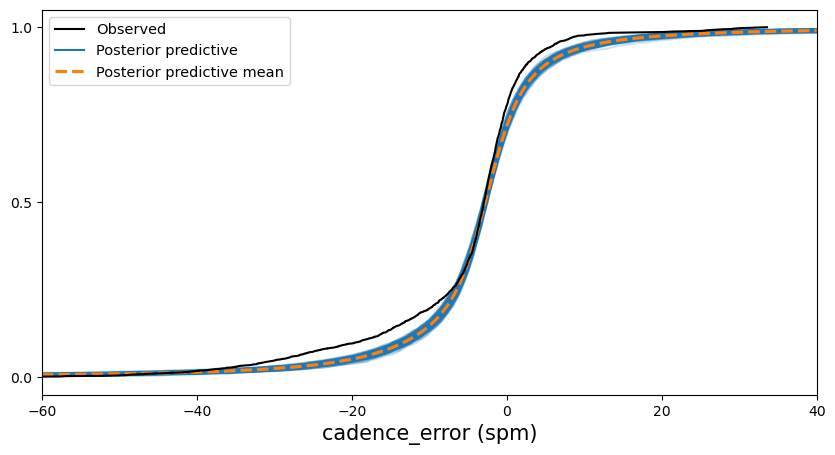

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
az.plot_ppc(idata_model_3, kind="cumulative", num_pp_samples=200, ax=ax)
ax.set_xlabel("cadence_error (spm)")
ax.set_xlim(-60, 40)
fig.savefig(f"{OUTPUT_PATH}model_3_ppc.png", dpi=200, bbox_inches="tight")
plt.show()

### PPC: Model 3

Identical to Model 2b. Same residual left-shoulder bump around -20 to -10. Sex did not absorb any of the asymmetry.

Confirms: the fat left tail is a within-sex phenomenon, not a between-sex one.

In [13]:
idata_model_3.to_netcdf("../data/processed/idata_model_3.nc")

az.summary(idata_model_3).to_csv(f"{OUTPUT_PATH}model_3_summary.csv")

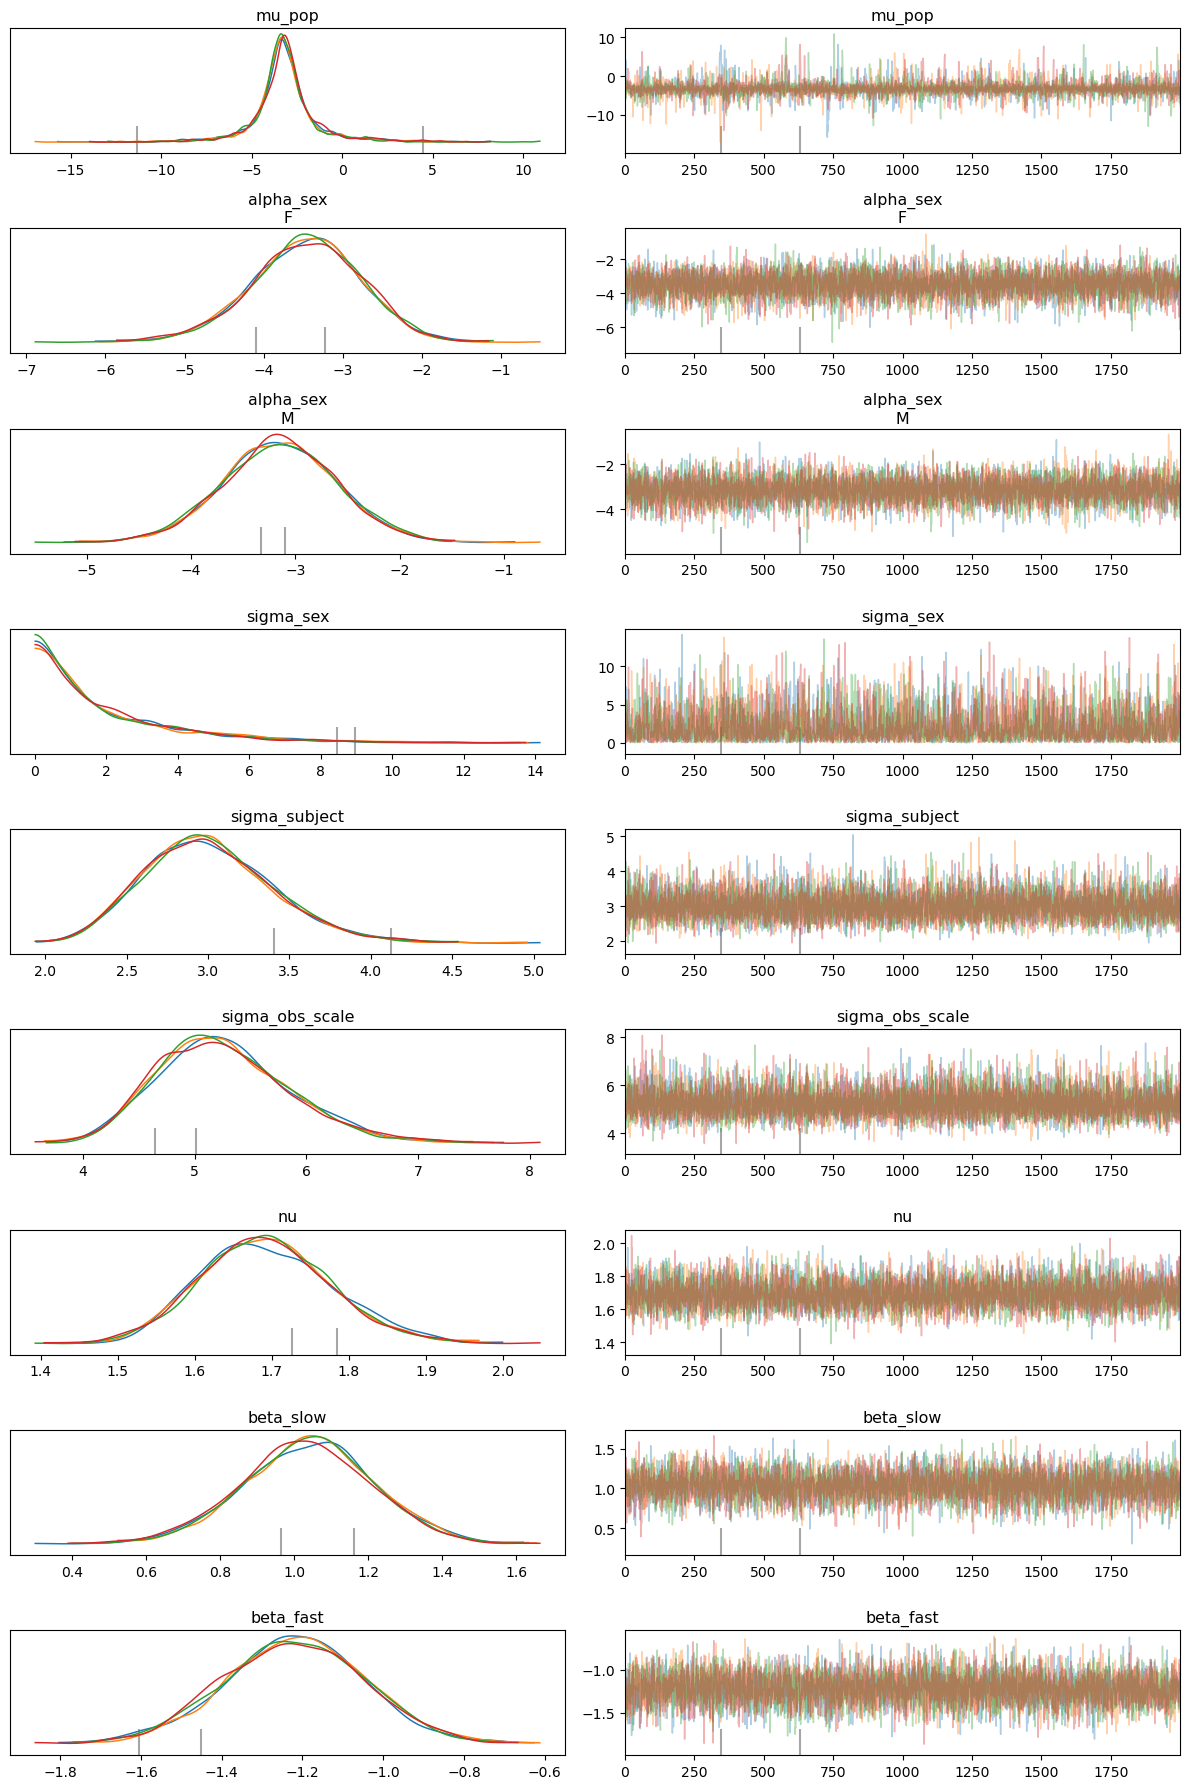

In [14]:
axes = az.plot_trace(
    idata_model_3,
    var_names=["mu_pop", "alpha_sex", "sigma_sex", "sigma_subject", "sigma_obs_scale", "nu", "beta_slow", "beta_fast"],
    compact=False,
)
fig = axes.ravel()[0].figure
fig.tight_layout()
fig.savefig(f"{OUTPUT_PATH}model_3_trace.png", dpi=200, bbox_inches="tight")
plt.show()

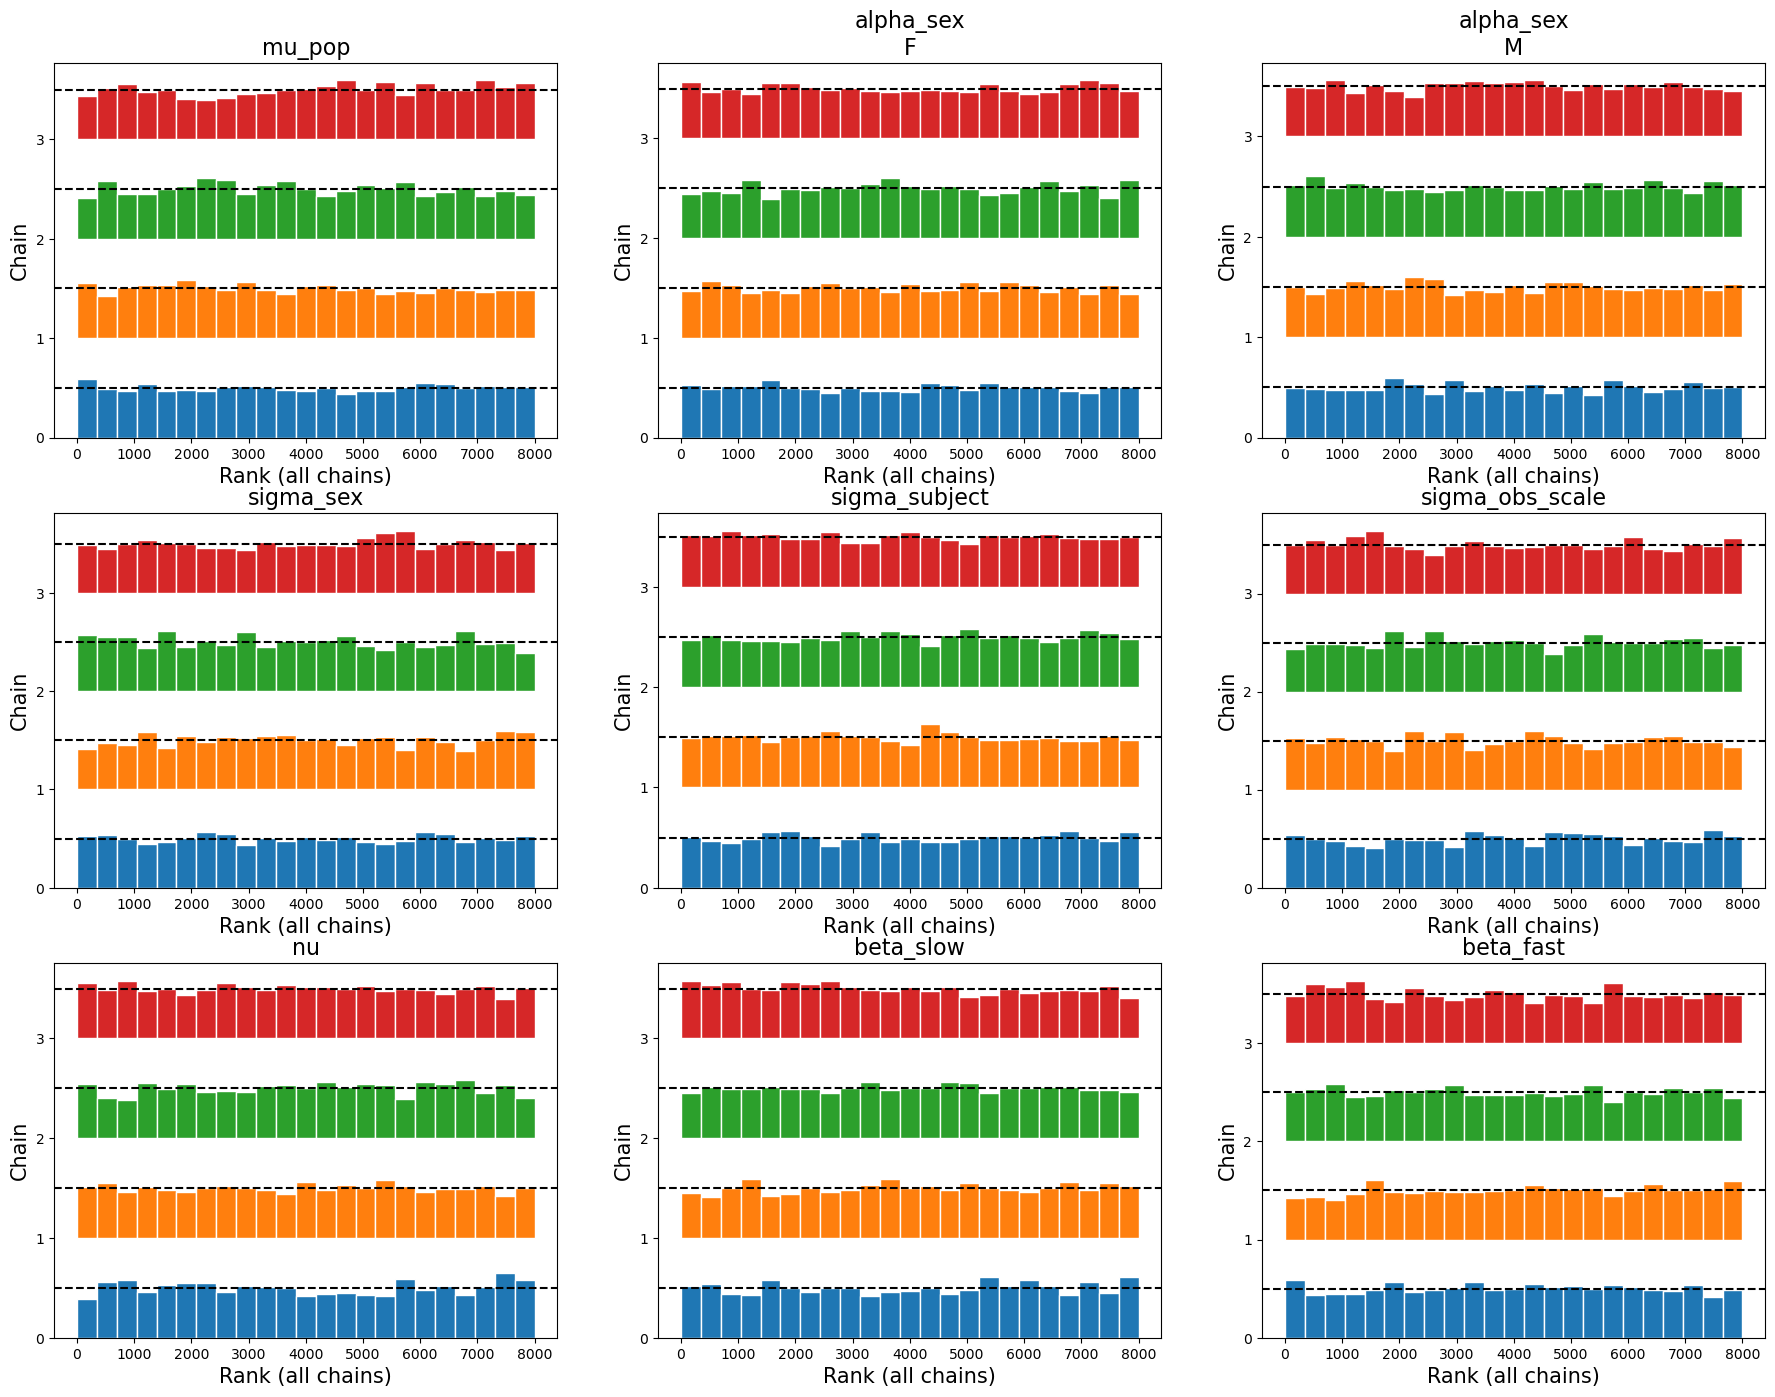

In [15]:
axes = az.plot_rank(
    idata_model_3,
    var_names=["mu_pop", "alpha_sex", "sigma_sex", "sigma_subject", "sigma_obs_scale", "nu", "beta_slow", "beta_fast"],
)
fig = axes.ravel()[0].figure
fig.savefig(f"{OUTPUT_PATH}model_3_rank.png", dpi=200, bbox_inches="tight")
plt.show()

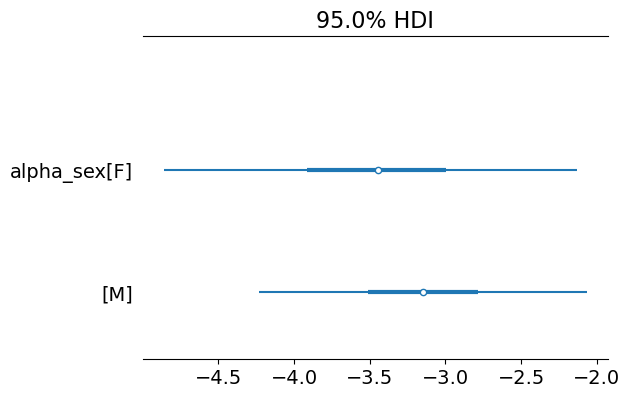

In [16]:
axes = az.plot_forest(
    idata_model_3,
    var_names=["alpha_sex"],
    combined=True,
    hdi_prob=0.95,
)
fig = axes[0].figure
fig.savefig(f"{OUTPUT_PATH}model_3_forest_alpha_sex.png", dpi=200, bbox_inches="tight")
plt.show()

In [17]:
loo_model_3 = az.loo(idata_model_3, pointwise=True)

loo_pointwise_m3 = pd.DataFrame({
    "elpd_i": loo_model_3.loo_i.values,
    "pareto_k": loo_model_3.pareto_k.values,
})
loo_pointwise_m3.to_csv(f"{OUTPUT_PATH}model_3_loo_pointwise.csv", index=False)

loo_headline_m3 = pd.DataFrame({
    "metric": ["elpd_loo", "se", "p_loo"],
    "value": [float(loo_model_3.elpd_loo), float(loo_model_3.se), float(loo_model_3.p_loo)],
})
loo_headline_m3.to_csv(f"{OUTPUT_PATH}model_3_loo_headline.csv", index=False)

loo_model_3

Computed from 8000 posterior samples and 2781 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -9306.44    75.87
p_loo      103.47        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     2781  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%